# CAR vs NON-CAR Image Classifier
## Supervised Machine Learning Pipeline

This notebook implements a complete ML pipeline for binary image classification:
- **Task**: Classify cropped vehicle images as CAR or NON-CAR
- **Method**: HOG (Histogram of Oriented Gradients) features + SVM classifier
- **Dataset**: Traffic Vehicles Object Detection (YOLO format)

---

### Pipeline Overview:
1. Load Dataset Metadata
2. Create Output Dataset Folders
3. Convert YOLO Annotations to Cropped Images
4. Dataset Sanity Check
5. Feature Extraction (HOG)
6. Train/Test Split
7. Train SVM Classifier
8. Model Evaluation

## 1. Import Required Libraries

In [1]:
# =============================================================================
# IMPORT REQUIRED LIBRARIES
# =============================================================================
# Image processing
import cv2
import numpy as np

# File system operations
import os
import glob
from pathlib import Path

# Feature extraction - HOG (Histogram of Oriented Gradients)
from skimage.feature import hog
from skimage import exposure

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Configuration & Dataset Metadata

Define paths and class information for the Traffic Vehicles Object Detection dataset.

In [ ]:
# =============================================================================
# CONFIGURATION & DATASET METADATA
# =============================================================================

# --- Path Configuration ---
# Base directory for the dataset
DATASET_ROOT = "Traffic Dataset"

# YOLO dataset structure paths
IMAGES_TRAIN_DIR = os.path.join(DATASET_ROOT, "images", "train")
LABELS_TRAIN_DIR = os.path.join(DATASET_ROOT, "labels", "train")

# Output directories for cropped images
OUTPUT_DIR = "dataset"
CAR_DIR = os.path.join(OUTPUT_DIR, "car")
NON_CAR_DIR = os.path.join(OUTPUT_DIR, "non_car")

# --- Class Definitions ---
# Traffic Vehicles Object Detection dataset class mapping
# Based on the Kaggle dataset structure
CLASS_NAMES = [
    "car",          # Class ID: 0
    "motorcycle",   # Class ID: 1
    "truck",        # Class ID: 2
    "bus",          # Class ID: 3
    "bicycle",      # Class ID: 4
    "pedestrian"    # Class ID: 5
]

# Identify the class ID for "car"
CAR_CLASS_ID = CLASS_NAMES.index("car")

# --- Image Processing Configuration ---
CROP_SIZE = (128, 128)  # Fixed size for all cropped images

print("=" * 60)
print("DATASET CONFIGURATION")
print("=" * 60)
print(f"Images Directory: {IMAGES_TRAIN_DIR}")
print(f"Labels Directory: {LABELS_TRAIN_DIR}")
print(f"Output Car Directory: {CAR_DIR}")
print(f"Output Non-Car Directory: {NON_CAR_DIR}")
print(f"\nClass Names: {CLASS_NAMES}")
print(f"Car Class ID: {CAR_CLASS_ID}")
print(f"Crop Size: {CROP_SIZE}")
print("=" * 60)

DATASET CONFIGURATION
Images Directory: Traffic Dataset\images\train
Labels Directory: Traffic Dataset\labels\train
Output Car Directory: dataset\car
Output Non-Car Directory: dataset\non_car

Class Names: ['car', 'motorcycle', 'truck', 'bus', 'bicycle', 'pedestrian']
Car Class ID: 0
Crop Size: (256, 256)


## 3. Create Output Dataset Folders

Create the directory structure for storing cropped car and non-car images.

In [3]:
# =============================================================================
# CREATE OUTPUT DATASET FOLDERS
# =============================================================================

def create_output_directories():
    """
    Create the output directory structure for storing cropped images.
    
    Structure:
        dataset/
            car/        <- Images of cars
            non_car/    <- Images of other vehicles/objects
    """
    # Create directories (exist_ok=True prevents errors if they already exist)
    os.makedirs(CAR_DIR, exist_ok=True)
    os.makedirs(NON_CAR_DIR, exist_ok=True)
    
    print("Output directories created successfully!")
    print(f"  - {CAR_DIR}")
    print(f"  - {NON_CAR_DIR}")

# Create the directories
create_output_directories()

Output directories created successfully!
  - dataset\car
  - dataset\non_car


## 4. Convert YOLO Annotations to Cropped Images

Parse YOLO format labels, extract bounding boxes, crop objects from images, and save them to the appropriate folders.

In [4]:
# =============================================================================
# YOLO FORMAT PARSING UTILITIES
# =============================================================================

def parse_yolo_label(label_path):
    """
    Parse a YOLO format label file.
    
    YOLO format: <class_id> <x_center> <y_center> <width> <height>
    All coordinates are normalized (0-1) relative to image dimensions.
    
    Args:
        label_path: Path to the .txt label file
        
    Returns:
        List of tuples: [(class_id, x_center, y_center, width, height), ...]
    """
    annotations = []
    
    try:
        with open(label_path, 'r') as f:
            for line in f:
                line = line.strip()
                if line:
                    parts = line.split()
                    if len(parts) >= 5:
                        class_id = int(parts[0])
                        x_center = float(parts[1])
                        y_center = float(parts[2])
                        width = float(parts[3])
                        height = float(parts[4])
                        annotations.append((class_id, x_center, y_center, width, height))
    except Exception as e:
        print(f"Error reading {label_path}: {e}")
    
    return annotations


def yolo_to_pixel_coords(x_center, y_center, width, height, img_width, img_height):
    """
    Convert YOLO normalized coordinates to pixel coordinates.
    
    YOLO format uses normalized coordinates (0-1), we need to convert
    to actual pixel coordinates for cropping.
    
    Args:
        x_center, y_center: Normalized center coordinates (0-1)
        width, height: Normalized bounding box dimensions (0-1)
        img_width, img_height: Actual image dimensions in pixels
        
    Returns:
        Tuple: (x_min, y_min, x_max, y_max) in pixel coordinates
    """
    # Convert normalized coordinates to pixels
    box_width = width * img_width
    box_height = height * img_height
    x_center_px = x_center * img_width
    y_center_px = y_center * img_height
    
    # Calculate corner coordinates
    x_min = int(x_center_px - box_width / 2)
    y_min = int(y_center_px - box_height / 2)
    x_max = int(x_center_px + box_width / 2)
    y_max = int(y_center_px + box_height / 2)
    
    # Ensure coordinates are within image bounds
    x_min = max(0, x_min)
    y_min = max(0, y_min)
    x_max = min(img_width, x_max)
    y_max = min(img_height, y_max)
    
    return x_min, y_min, x_max, y_max


def crop_and_resize(image, bbox, target_size=CROP_SIZE):
    """
    Crop a region from the image and resize to fixed dimensions.
    
    Args:
        image: Input image (numpy array)
        bbox: Bounding box coordinates (x_min, y_min, x_max, y_max)
        target_size: Output image size (width, height)
        
    Returns:
        Resized cropped image or None if invalid
    """
    x_min, y_min, x_max, y_max = bbox
    
    # Validate crop region
    if x_max <= x_min or y_max <= y_min:
        return None
    
    # Crop the region
    crop = image[y_min:y_max, x_min:x_max]
    
    # Check if crop is valid
    if crop.size == 0:
        return None
    
    # Resize to fixed dimensions
    try:
        resized = cv2.resize(crop, target_size, interpolation=cv2.INTER_AREA)
        return resized
    except Exception:
        return None


print("YOLO parsing utilities defined!")

YOLO parsing utilities defined!


In [5]:
# =============================================================================
# PROCESS DATASET - EXTRACT AND SAVE CROPPED IMAGES
# =============================================================================

def get_image_extensions():
    """Return list of supported image file extensions."""
    return ['.jpg', '.jpeg', '.png', '.bmp']


def find_image_file(images_dir, base_name):
    """
    Find an image file with any supported extension.
    
    Args:
        images_dir: Directory to search
        base_name: Base filename without extension
        
    Returns:
        Full path to image file or None if not found
    """
    for ext in get_image_extensions():
        img_path = os.path.join(images_dir, base_name + ext)
        if os.path.exists(img_path):
            return img_path
    return None


def process_dataset():
    """
    Process all images and labels to create cropped dataset.
    
    For each image:
    1. Read the corresponding YOLO label file
    2. Extract all bounding boxes
    3. Crop and resize each object
    4. Save to car/ or non_car/ folder based on class
    
    Returns:
        Dictionary with processing statistics
    """
    stats = {
        'total_images': 0,
        'total_objects': 0,
        'car_count': 0,
        'non_car_count': 0,
        'skipped': 0,
        'errors': 0
    }
    
    # Clear existing cropped images (optional - for clean re-run)
    for folder in [CAR_DIR, NON_CAR_DIR]:
        for f in glob.glob(os.path.join(folder, '*')):
            os.remove(f)
    
    # Get all label files
    label_files = glob.glob(os.path.join(LABELS_TRAIN_DIR, '*.txt'))
    print(f"Found {len(label_files)} label files to process...")
    
    # Process each label file
    for label_path in tqdm(label_files, desc="Processing images"):
        # Get base filename (without extension)
        base_name = os.path.splitext(os.path.basename(label_path))[0]
        
        # Find corresponding image file
        image_path = find_image_file(IMAGES_TRAIN_DIR, base_name)
        
        if image_path is None:
            stats['errors'] += 1
            continue
        
        # Read the image
        image = cv2.imread(image_path)
        if image is None:
            stats['errors'] += 1
            continue
        
        stats['total_images'] += 1
        img_height, img_width = image.shape[:2]
        
        # Parse YOLO annotations
        annotations = parse_yolo_label(label_path)
        
        # Process each annotation
        for idx, (class_id, x_center, y_center, width, height) in enumerate(annotations):
            stats['total_objects'] += 1
            
            # Convert YOLO coordinates to pixel coordinates
            bbox = yolo_to_pixel_coords(
                x_center, y_center, width, height,
                img_width, img_height
            )
            
            # Crop and resize
            cropped = crop_and_resize(image, bbox)
            
            if cropped is None:
                stats['skipped'] += 1
                continue
            
            # Determine output directory based on class
            if class_id == CAR_CLASS_ID:
                output_dir = CAR_DIR
                stats['car_count'] += 1
            else:
                output_dir = NON_CAR_DIR
                stats['non_car_count'] += 1
            
            # Generate unique filename
            output_filename = f"{base_name}_obj{idx}.jpg"
            output_path = os.path.join(output_dir, output_filename)
            
            # Save cropped image
            cv2.imwrite(output_path, cropped)
    
    return stats


# Run the processing
print("=" * 60)
print("EXTRACTING CROPPED IMAGES FROM YOLO DATASET")
print("=" * 60)

stats = process_dataset()

print("\n" + "=" * 60)
print("PROCESSING COMPLETE - STATISTICS")
print("=" * 60)
print(f"Total images processed: {stats['total_images']}")
print(f"Total objects extracted: {stats['total_objects']}")
print(f"  - Cars: {stats['car_count']}")
print(f"  - Non-cars: {stats['non_car_count']}")
print(f"Skipped (invalid crops): {stats['skipped']}")
print(f"Errors: {stats['errors']}")
print("=" * 60)

EXTRACTING CROPPED IMAGES FROM YOLO DATASET
Found 738 label files to process...


Processing images: 100%|██████████| 738/738 [00:33<00:00, 22.06it/s]


PROCESSING COMPLETE - STATISTICS
Total images processed: 738
Total objects extracted: 9154
  - Cars: 4116
  - Non-cars: 5037
Skipped (invalid crops): 1
Errors: 0


## 5. Dataset Sanity Check

Verify the cropped dataset was created correctly and visualize some sample images.

In [6]:
# =============================================================================
# DATASET SANITY CHECK
# =============================================================================

def count_images_in_folder(folder_path):
    """Count the number of image files in a folder."""
    count = 0
    for ext in get_image_extensions():
        count += len(glob.glob(os.path.join(folder_path, f'*{ext}')))
    return count


def dataset_sanity_check():
    """
    Perform sanity checks on the created dataset.
    
    Prints:
    - Number of car images
    - Number of non-car images
    - Class balance ratio
    """
    car_count = count_images_in_folder(CAR_DIR)
    non_car_count = count_images_in_folder(NON_CAR_DIR)
    total = car_count + non_car_count
    
    print("=" * 60)
    print("DATASET SANITY CHECK")
    print("=" * 60)
    print(f"\nCar images:     {car_count:,}")
    print(f"Non-car images: {non_car_count:,}")
    print(f"Total images:   {total:,}")
    
    if total > 0:
        car_ratio = car_count / total * 100
        print(f"\nClass distribution:")
        print(f"   - Car:     {car_ratio:.1f}%")
        print(f"   - Non-car: {100 - car_ratio:.1f}%")
        
        # Check for class imbalance
        if car_ratio < 30 or car_ratio > 70:
            print("\nWARNING: Significant class imbalance detected!")
            print("   Consider using stratified sampling or class weights.")
    
    print("=" * 60)
    
    return car_count, non_car_count


# Run sanity check
car_count, non_car_count = dataset_sanity_check()

DATASET SANITY CHECK

Car images:     4,116
Non-car images: 5,037
Total images:   9,153

Class distribution:
   - Car:     45.0%
   - Non-car: 55.0%


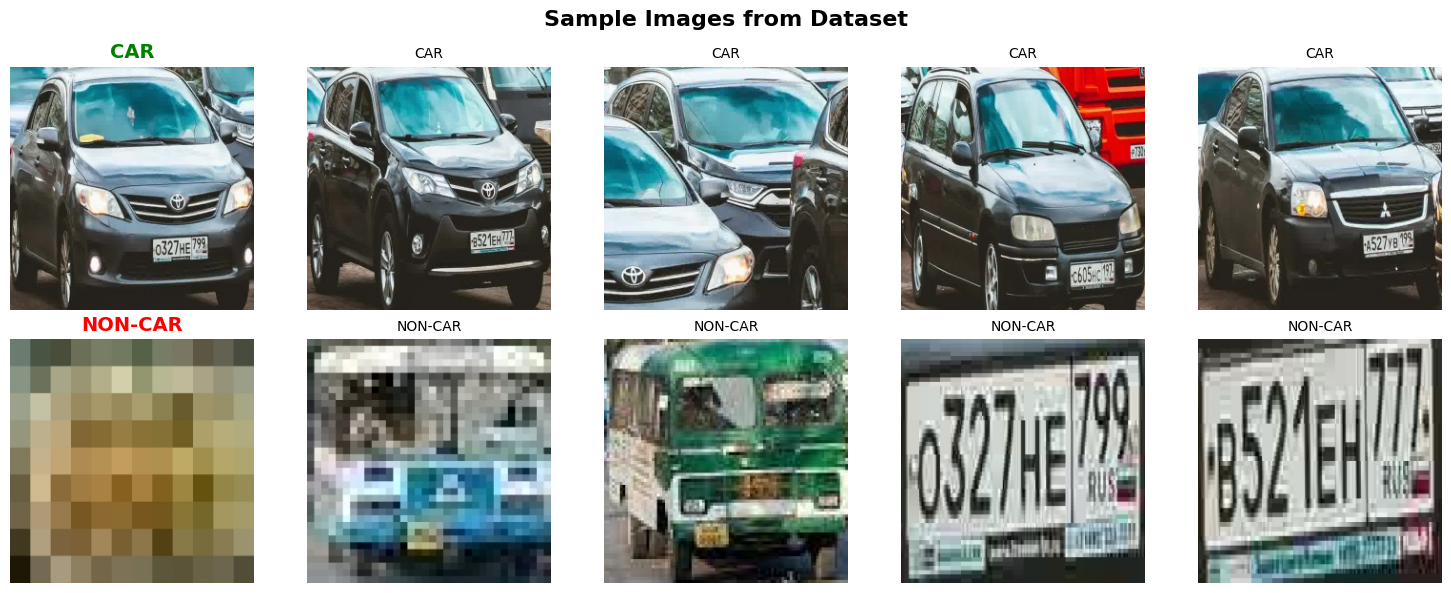

In [7]:
# =============================================================================
# VISUALIZE SAMPLE IMAGES FROM DATASET
# =============================================================================

def visualize_samples(num_samples=5):
    """
    Display sample images from both car and non-car categories.
    
    Args:
        num_samples: Number of samples to show from each category
    """
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))
    
    # Get sample car images
    car_images = glob.glob(os.path.join(CAR_DIR, '*.jpg'))[:num_samples]
    
    # Get sample non-car images
    non_car_images = glob.glob(os.path.join(NON_CAR_DIR, '*.jpg'))[:num_samples]
    
    # Display car samples
    for i, img_path in enumerate(car_images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('CAR', fontsize=14, fontweight='bold', color='green')
        else:
            axes[0, i].set_title('CAR', fontsize=10)
    
    # Display non-car samples
    for i, img_path in enumerate(non_car_images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[1, i].imshow(img)
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('NON-CAR', fontsize=14, fontweight='bold', color='red')
        else:
            axes[1, i].set_title('NON-CAR', fontsize=10)
    
    plt.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Visualize samples
visualize_samples(num_samples=5)

## 6. Feature Extraction with HOG

Extract Histogram of Oriented Gradients (HOG) features from all cropped images.

**HOG Features:**
- Captures edge and gradient structure
- Robust to geometric and photometric transformations
- Excellent for object recognition tasks
- No pretrained weights required

In [8]:
# =============================================================================
# HOG FEATURE EXTRACTION
# =============================================================================

# HOG Parameters
HOG_ORIENTATIONS = 9       # Number of orientation bins
HOG_PIXELS_PER_CELL = (8, 8)  # Size of a cell
HOG_CELLS_PER_BLOCK = (2, 2)  # Number of cells in each block


def extract_hog_features(image):
    """
    Extract HOG features from a single image.
    
    HOG (Histogram of Oriented Gradients) captures edge and gradient
    structure that is very useful for object recognition.
    
    Args:
        image: Input image (can be color or grayscale)
        
    Returns:
        1D numpy array of HOG features
    """
    # Convert to grayscale if needed
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    
    # Extract HOG features
    features = hog(
        gray,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm='L2-Hys',
        visualize=False,
        feature_vector=True
    )
    
    return features


def load_dataset_with_features():
    """
    Load all cropped images and extract HOG features.
    
    Returns:
        X: Feature matrix (n_samples, n_features)
        y: Labels array (n_samples,) where car=1, non_car=0
    """
    X = []  # Feature vectors
    y = []  # Labels
    
    # Process car images (label = 1)
    car_images = glob.glob(os.path.join(CAR_DIR, '*.jpg'))
    print(f"Processing {len(car_images)} car images...")
    
    for img_path in tqdm(car_images, desc="Extracting HOG (cars)"):
        image = cv2.imread(img_path)
        if image is not None:
            features = extract_hog_features(image)
            X.append(features)
            y.append(1)  # Car label
    
    # Process non-car images (label = 0)
    non_car_images = glob.glob(os.path.join(NON_CAR_DIR, '*.jpg'))
    print(f"Processing {len(non_car_images)} non-car images...")
    
    for img_path in tqdm(non_car_images, desc="Extracting HOG (non-cars)"):
        image = cv2.imread(img_path)
        if image is not None:
            features = extract_hog_features(image)
            X.append(features)
            y.append(0)  # Non-car label
    
    # Convert to numpy arrays
    X = np.array(X)
    y = np.array(y)
    
    return X, y


# Extract features from all images
print("=" * 60)
print("FEATURE EXTRACTION - HOG (Histogram of Oriented Gradients)")
print("=" * 60)
print(f"\nHOG Parameters:")
print(f"  - Orientations: {HOG_ORIENTATIONS}")
print(f"  - Pixels per cell: {HOG_PIXELS_PER_CELL}")
print(f"  - Cells per block: {HOG_CELLS_PER_BLOCK}")
print()

X, y = load_dataset_with_features()

print("\n" + "=" * 60)
print("FEATURE EXTRACTION COMPLETE")
print("=" * 60)
print(f"Feature matrix shape: {X.shape}")
print(f"  - Number of samples: {X.shape[0]}")
print(f"  - Number of features per sample: {X.shape[1]}")
print(f"Labels shape: {y.shape}")
print(f"  - Car samples (y=1): {np.sum(y == 1)}")
print(f"  - Non-car samples (y=0): {np.sum(y == 0)}")
print("=" * 60)

FEATURE EXTRACTION - HOG (Histogram of Oriented Gradients)

HOG Parameters:
  - Orientations: 9
  - Pixels per cell: (8, 8)
  - Cells per block: (2, 2)

Processing 4116 car images...


Extracting HOG (cars): 100%|██████████| 4116/4116 [03:27<00:00, 19.84it/s]


Processing 5037 non-car images...


Extracting HOG (non-cars): 100%|██████████| 5037/5037 [04:07<00:00, 20.32it/s]



FEATURE EXTRACTION COMPLETE
Feature matrix shape: (9153, 34596)
  - Number of samples: 9153
  - Number of features per sample: 34596
Labels shape: (9153,)
  - Car samples (y=1): 4116
  - Non-car samples (y=0): 5037


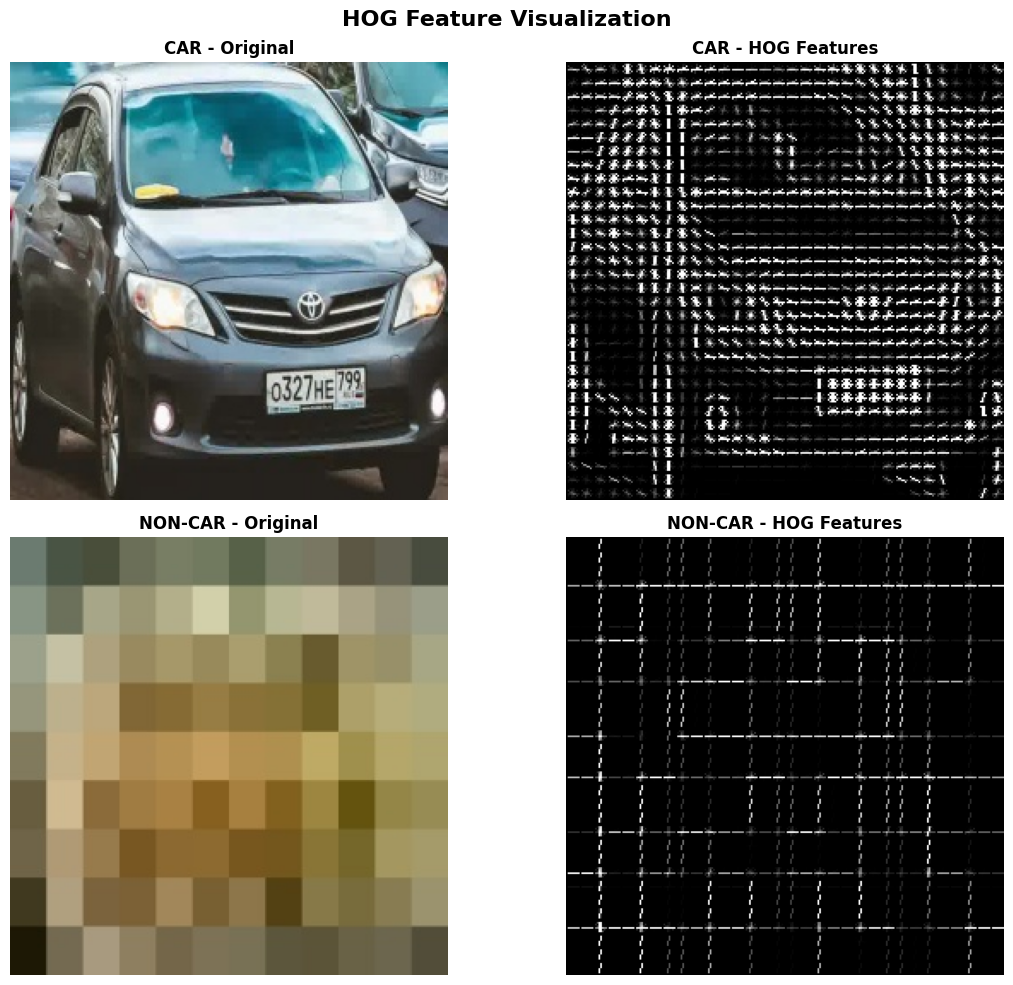

In [9]:
# =============================================================================
# VISUALIZE HOG FEATURES
# =============================================================================

def visualize_hog_features():
    """
    Visualize HOG features for a sample car and non-car image.
    Shows original image alongside its HOG representation.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Get sample images
    car_sample = glob.glob(os.path.join(CAR_DIR, '*.jpg'))[0]
    non_car_sample = glob.glob(os.path.join(NON_CAR_DIR, '*.jpg'))[0]
    
    for idx, (img_path, label) in enumerate([(car_sample, 'CAR'), (non_car_sample, 'NON-CAR')]):
        # Read and convert image
        image = cv2.imread(img_path)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Extract HOG with visualization
        features, hog_image = hog(
            gray,
            orientations=HOG_ORIENTATIONS,
            pixels_per_cell=HOG_PIXELS_PER_CELL,
            cells_per_block=HOG_CELLS_PER_BLOCK,
            block_norm='L2-Hys',
            visualize=True,
            feature_vector=True
        )
        
        # Rescale HOG image for better visualization
        hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
        
        # Plot original image
        axes[idx, 0].imshow(rgb)
        axes[idx, 0].set_title(f'{label} - Original', fontsize=12, fontweight='bold')
        axes[idx, 0].axis('off')
        
        # Plot HOG visualization
        axes[idx, 1].imshow(hog_image_rescaled, cmap='gray')
        axes[idx, 1].set_title(f'{label} - HOG Features', fontsize=12, fontweight='bold')
        axes[idx, 1].axis('off')
    
    plt.suptitle('HOG Feature Visualization', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Visualize HOG features
visualize_hog_features()

## 7. Train/Test Split

Split the dataset into training (80%) and testing (20%) sets with stratified sampling to maintain class distribution.

In [10]:
# =============================================================================
# TRAIN/TEST SPLIT
# =============================================================================

# Split parameters
TEST_SIZE = 0.2  # 20% for testing
RANDOM_STATE = 42  # For reproducibility

# Perform stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y  # Maintain class distribution in both sets
)

print("=" * 60)
print("TRAIN/TEST SPLIT")
print("=" * 60)
print(f"\nSplit ratio: {int((1-TEST_SIZE)*100)}% train / {int(TEST_SIZE*100)}% test")
print(f"Random state: {RANDOM_STATE}")
print(f"\nTraining set:")
print(f"   - Total samples: {len(X_train)}")
print(f"   - Cars (y=1): {np.sum(y_train == 1)}")
print(f"   - Non-cars (y=0): {np.sum(y_train == 0)}")
print(f"\nTest set:")
print(f"   - Total samples: {len(X_test)}")
print(f"   - Cars (y=1): {np.sum(y_test == 1)}")
print(f"   - Non-cars (y=0): {np.sum(y_test == 0)}")
print("=" * 60)

TRAIN/TEST SPLIT

Split ratio: 80% train / 20% test
Random state: 42

Training set:
   - Total samples: 7322
   - Cars (y=1): 3293
   - Non-cars (y=0): 4029

Test set:
   - Total samples: 1831
   - Cars (y=1): 823
   - Non-cars (y=0): 1008


## 8. Train SVM Classifier

Train a Support Vector Machine (SVM) with linear kernel for binary classification.

**Why SVM?**
- Effective for high-dimensional feature spaces
- Works well with HOG features
- Provides good generalization with proper margins
- No pretrained weights - purely classical ML

In [ ]:
# =============================================================================
# TRAIN SVM CLASSIFIER
# =============================================================================
import time

# Initialize SVM classifier with linear kernel
# Linear kernel works well with HOG features due to high-dimensional space
svm_classifier = SVC(
    kernel='linear',     # Linear kernel for better interpretability and speed
    C=1.0,              # Regularization parameter
    random_state=RANDOM_STATE,
    probability=True     # Enable probability estimates (useful for later integration)
)

print("=" * 60)
print("TRAINING SVM CLASSIFIER")
print("=" * 60)
print(f"\nClassifier: Support Vector Machine (SVM)")
print(f"Kernel: Linear")
print(f"Regularization (C): 1.0")
print(f"\nTraining on {len(X_train)} samples...")

# Train the classifier and measure time
start_time = time.time()
svm_classifier.fit(X_train, y_train)
training_time = time.time() - start_time

print(f"\nTraining complete!")
print(f"Training time: {training_time:.2f} seconds")
print("=" * 60)

TRAINING SVM CLASSIFIER

Classifier: Support Vector Machine (SVM)
Kernel: Linear
Regularization (C): 3.0

Training on 7322 samples...


## 9. Model Evaluation

Evaluate the trained classifier on the test set with multiple metrics:
- **Accuracy**: Overall correctness
- **Precision**: True positives / Predicted positives
- **Recall**: True positives / Actual positives  
- **F1-Score**: Harmonic mean of precision and recall
- **Confusion Matrix**: Visual representation of predictions vs ground truth

In [ ]:
# =============================================================================
# MODEL EVALUATION - PREDICTIONS
# =============================================================================

# Make predictions on test set
print("Making predictions on test set...")
y_pred = svm_classifier.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "=" * 60)
print("MODEL EVALUATION RESULTS")
print("=" * 60)
print(f"\nPerformance Metrics:")
print(f"   ┌─────────────────────────────────┐")
print(f"   │ Accuracy:   {accuracy:.4f} ({accuracy*100:.2f}%)   │")
print(f"   │ Precision:  {precision:.4f} ({precision*100:.2f}%)   │")
print(f"   │ Recall:     {recall:.4f} ({recall*100:.2f}%)   │")
print(f"   │ F1-Score:   {f1:.4f} ({f1*100:.2f}%)   │")
print(f"   └─────────────────────────────────┘")
print()

# Detailed classification report
print("Detailed Classification Report:")
print("-" * 60)
print(classification_report(y_test, y_pred, target_names=['Non-Car', 'Car']))
print("=" * 60)

Making predictions on test set...

MODEL EVALUATION RESULTS

Performance Metrics:
   ┌─────────────────────────────────┐
   │ Accuracy:   0.8946 (89.46%)   │
   │ Precision:  0.8786 (87.86%)   │
   │ Recall:     0.8882 (88.82%)   │
   │ F1-Score:   0.8834 (88.34%)   │
   └─────────────────────────────────┘

Detailed Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

     Non-Car       0.91      0.90      0.90      1008
         Car       0.88      0.89      0.88       823

    accuracy                           0.89      1831
   macro avg       0.89      0.89      0.89      1831
weighted avg       0.89      0.89      0.89      1831



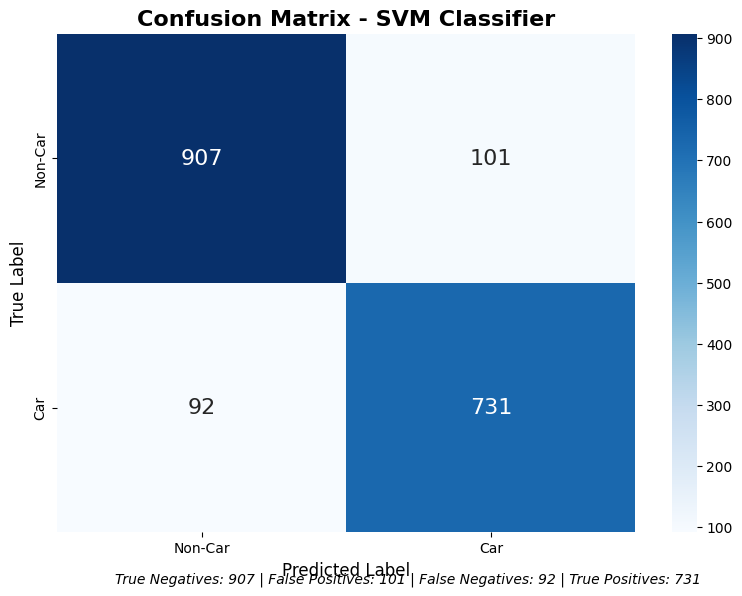


Confusion Matrix Interpretation:
   - True Negatives (Non-car correctly identified): 907
   - False Positives (Non-car misclassified as car): 101
   - False Negatives (Car misclassified as non-car): 92
   - True Positives (Car correctly identified): 731


In [ ]:
# =============================================================================
# CONFUSION MATRIX VISUALIZATION
# =============================================================================

def plot_confusion_matrix(y_true, y_pred):
    """
    Create and display a confusion matrix heatmap.
    
    Args:
        y_true: Ground truth labels
        y_pred: Predicted labels
    """
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Create figure
    plt.figure(figsize=(8, 6))
    
    # Create heatmap
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Non-Car', 'Car'],
        yticklabels=['Non-Car', 'Car'],
        annot_kws={'size': 16}
    )
    
    plt.title('Confusion Matrix - SVM Classifier', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    
    # Add text annotations
    total = cm.sum()
    tn, fp, fn, tp = cm.ravel()
    
    plt.figtext(0.15, 0.02, 
                f"True Negatives: {tn} | False Positives: {fp} | False Negatives: {fn} | True Positives: {tp}",
                ha='left', fontsize=10, style='italic')
    
    plt.tight_layout()
    plt.show()
    
    # Print interpretation
    print("\nConfusion Matrix Interpretation:")
    print(f"   - True Negatives (Non-car correctly identified): {tn}")
    print(f"   - False Positives (Non-car misclassified as car): {fp}")
    print(f"   - False Negatives (Car misclassified as non-car): {fn}")
    print(f"   - True Positives (Car correctly identified): {tp}")


# Display confusion matrix
plot_confusion_matrix(y_test, y_pred)

## 10. Save Model for Video Pipeline Integration

Save the trained classifier and feature extraction parameters for use in the car-counting video pipeline.

In [ ]:
# =============================================================================
# SAVE MODEL FOR VIDEO PIPELINE INTEGRATION
# =============================================================================
import joblib

# Define model filename
MODEL_FILENAME = 'car_classifier_svm.joblib'

# Save the trained model
joblib.dump(svm_classifier, MODEL_FILENAME)

# Save model configuration for later use
model_config = {
    'crop_size': CROP_SIZE,
    'hog_orientations': HOG_ORIENTATIONS,
    'hog_pixels_per_cell': HOG_PIXELS_PER_CELL,
    'hog_cells_per_block': HOG_CELLS_PER_BLOCK,
    'class_names': ['non_car', 'car'],
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1
}

CONFIG_FILENAME = 'car_classifier_config.joblib'
joblib.dump(model_config, CONFIG_FILENAME)

print("=" * 60)
print("MODEL SAVED FOR VIDEO PIPELINE INTEGRATION")
print("=" * 60)
print(f"\Model saved to: {MODEL_FILENAME}")
print(f"Config saved to: {CONFIG_FILENAME}")
print("\nTo use in video pipeline:")
print("  1. Load model: clf = joblib.load('car_classifier_svm.joblib')")
print("  2. Load config: cfg = joblib.load('car_classifier_config.joblib')")
print("  3. Extract HOG features from detected objects")
print("  4. Predict: clf.predict(hog_features)")
print("=" * 60)

MODEL SAVED FOR VIDEO PIPELINE INTEGRATION
\Model saved to: car_classifier_svm.joblib
Config saved to: car_classifier_config.joblib

To use in video pipeline:
  1. Load model: clf = joblib.load('car_classifier_svm.joblib')
  2. Load config: cfg = joblib.load('car_classifier_config.joblib')
  3. Extract HOG features from detected objects
  4. Predict: clf.predict(hog_features)


## 11. Test Prediction Function

Create and test a prediction function that can be used in the video pipeline.

In [ ]:
# =============================================================================
# PREDICTION FUNCTION FOR VIDEO PIPELINE INTEGRATION
# =============================================================================

def predict_car(image, classifier=svm_classifier):
    """
    Predict if an image crop contains a car.
    
    This function can be integrated into a video car-counting pipeline.
    
    Args:
        image: Cropped image region (BGR format from OpenCV)
        classifier: Trained SVM classifier
        
    Returns:
        Tuple: (is_car, confidence)
            is_car: Boolean, True if car detected
            confidence: Float, prediction probability
    """
    # Resize to expected dimensions
    resized = cv2.resize(image, CROP_SIZE)
    
    # Extract HOG features
    features = extract_hog_features(resized)
    
    # Reshape for prediction (single sample)
    features = features.reshape(1, -1)
    
    # Get prediction
    prediction = classifier.predict(features)[0]
    
    # Get probability if available
    if hasattr(classifier, 'predict_proba'):
        proba = classifier.predict_proba(features)[0]
        confidence = proba[prediction]
    else:
        confidence = 1.0
    
    is_car = (prediction == 1)
    
    return is_car, confidence


# Test the prediction function on sample images
print("=" * 60)
print("TESTING PREDICTION FUNCTION")
print("=" * 60)

# Test on car samples
car_samples = glob.glob(os.path.join(CAR_DIR, '*.jpg'))[:3]
print("\nTesting on CAR samples:")
for img_path in car_samples:
    img = cv2.imread(img_path)
    is_car, conf = predict_car(img)
    status = "CORRECT" if is_car else "WRONG"
    print(f"   {os.path.basename(img_path)}: is_car={is_car}, confidence={conf:.2f} {status}")

# Test on non-car samples
non_car_samples = glob.glob(os.path.join(NON_CAR_DIR, '*.jpg'))[:3]
print("\nTesting on NON-CAR samples:")
for img_path in non_car_samples:
    img = cv2.imread(img_path)
    is_car, conf = predict_car(img)
    status = "CORRECT" if not is_car else "WRONG"
    print(f"   {os.path.basename(img_path)}: is_car={is_car}, confidence={conf:.2f} {status}")

print("\n" + "=" * 60)

TESTING PREDICTION FUNCTION

Testing on CAR samples:
   00 (100)_obj0.jpg: is_car=True, confidence=0.97 CORRECT
   00 (100)_obj1.jpg: is_car=True, confidence=1.00 CORRECT
   00 (100)_obj2.jpg: is_car=True, confidence=0.97 CORRECT

Testing on NON-CAR samples:
   00 (10)_obj0.jpg: is_car=False, confidence=0.82 CORRECT
   00 (10)_obj1.jpg: is_car=False, confidence=0.89 CORRECT
   00 (10)_obj2.jpg: is_car=False, confidence=0.82 CORRECT



## Summary

### Pipeline Complete!

This notebook implemented a complete supervised ML pipeline for CAR vs NON-CAR classification:

| Step | Description | Status |
|------|-------------|--------|
| 1 | Load Dataset Metadata | ✓ |
| 2 | Create Output Folders | ✓ |
| 3 | Convert YOLO → Cropped Images | ✓ |
| 4 | Dataset Sanity Check | ✓ |
| 5 | Feature Extraction (HOG) | ✓ |
| 6 | Train/Test Split | ✓ |
| 7 | Train SVM Classifier | ✓ |
| 8 | Model Evaluation | ✓ |

### Key Characteristics:
- **HOG features** - Captures edge/gradient structure
- **SVM classifier** - Linear kernel for high-dimensional data
- **Ready for integration** - Model saved for video pipeline use

### Files Generated:
- `dataset/car/` - Cropped car images
- `dataset/non_car/` - Cropped non-car images  
- `car_classifier_svm.joblib` - Trained model
- `car_classifier_config.joblib` - Model configuration